# **RF, CNN, FNN Using MNIST Dataset**

In [2]:
# Libraries for data manipulation and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MNIST dataset available in Keras
from keras.datasets import mnist

# Facade class for model selection and prediction
from classifier import MnistClassifier

# Libraries for evaluation the perfomance of our model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Library for working with image
from PIL import Image

# EDA

MNIST is a dataset consisting of handwritten digit images. The objective of this task is to build models that can accurately predict the label of each image. To achieve this, we apply both classical machine learning and deep learning approaches, including Random Forest, a Feedforward Neural Network and a Convolutional Neural Network

Let's start by loading the data and checking the shapes of X_train, X_test, y_train, and y_test:

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Shape of training data: {X_train.shape}, {y_train.shape}")
print(f"Shape of testing data: {X_test.shape}, {y_test.shape}")
print(f"Data type of data: {X_train[0].dtype}, {y_train[0].dtype}")

Shape of training data: (60000, 28, 28), (60000,)
Shape of testing data: (10000, 28, 28), (10000,)
Data type of data: uint8, uint8


We also need to check how many different digits (classes) are present in the dataset:

In [5]:
unique_labels = np.unique(y_train)

print(f"Unique labels: {unique_labels}")
print(f"Number of unique labels: {len(unique_labels)}")

Unique labels: [0 1 2 3 4 5 6 7 8 9]
Number of unique labels: 10


The training dataset contains 60000 images, each represented as a 28 х 28 pixel grid. Each image corresponds to a handwritten digit from 0 to 9, giving a total of 10 classes

Let's explore class distribution

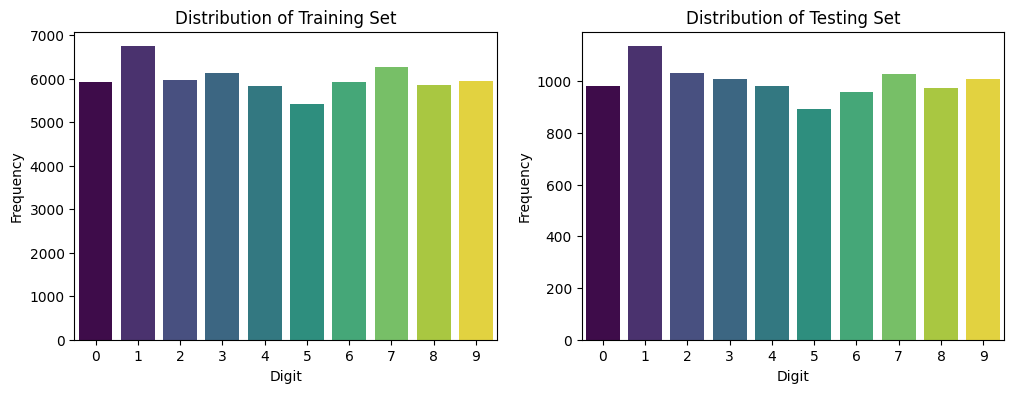

In [5]:
target = [y_train, y_test]
titles = ["Training Set", "Testing Set"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for data, ax, title in zip(target, axes, titles):
    sns.countplot(x=data, ax=ax, palette="viridis", hue=data, legend=False)
    ax.set_xlabel("Digit")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {title}")

As we can see, the class distribution is nearly uniform, so there is no need for additional class balancing

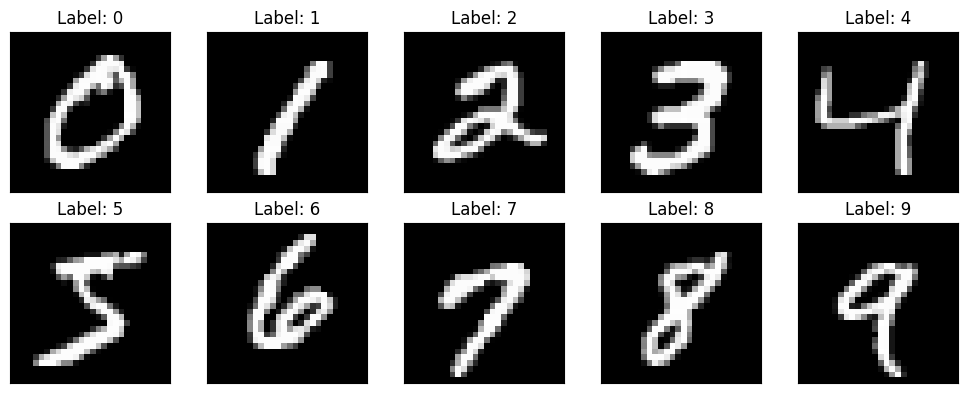

In [106]:
unique_digits = []

for i in range(10):
    index = np.where(y_train == i)[0][0]
    unique_digits.append(index)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for i, idx in enumerate(unique_digits):
    ax = axes[i]
    ax.imshow(X_train[idx], cmap="gist_gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Label: {y_train[idx]}")
    
plt.tight_layout()

We have visualized a representative image for each digit (0–9). It is important to note that these images are not identical across all samples of the same class - they simply show one typical example per digit. Handwritten characters naturally vary in style, thickness, and positioning


# Preprocessing & Training 

All data preprocessing and model training logic is implemented in our classifier classes. So we are now ready to move on to building and evaluating the performance of each model

**Training Models**

So we need to pass the algorithm name to our MnistClassifier and build the corresponding model based on that algorithm. Therefore, let's check this now

In [4]:
rf_clf = MnistClassifier(algorithm="rf")
rf_clf.train(X_train, y_train)

In [5]:
cnn_clf = MnistClassifier(algorithm="cnn")
cnn_clf.train(X_train, y_train)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9449 - loss: 0.1862 - val_accuracy: 0.7597 - val_loss: 0.7756
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9801 - loss: 0.0687 - val_accuracy: 0.9898 - val_loss: 0.0399
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9843 - loss: 0.0512 - val_accuracy: 0.9902 - val_loss: 0.0365
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9870 - loss: 0.0415 - val_accuracy: 0.9895 - val_loss: 0.0345
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9887 - loss: 0.0361 - val_accuracy: 0.9908 - val_loss: 0.0331
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9895 - loss: 0.0318 - val_accuracy: 0.9908 - val_loss: 0.0316
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9908 - loss: 0.0287 - val_accuracy: 0.9885 - val_loss: 0.0387
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9913 - loss: 0.0269 - 

CNN utilized all 15 out of 15 allocated epochs. The validation loss continued to decrease throughout the entire training process and the EarlyStopping callback was never triggered

In [6]:
nn_clf = MnistClassifier(algorithm="nn")
nn_clf.train(X_train, y_train)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8697 - loss: 0.4369 - val_accuracy: 0.9613 - val_loss: 0.1391
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9366 - loss: 0.2135 - val_accuracy: 0.9692 - val_loss: 0.1072
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9507 - loss: 0.1655 - val_accuracy: 0.9740 - val_loss: 0.0884
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9588 - loss: 0.1378 - val_accuracy: 0.9717 - val_loss: 0.0896
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9628 - loss: 0.1206 - val_accuracy: 0.9755 - val_loss: 0.0812
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9661 - loss: 0.1089 - val_accuracy: 0.9775 - val_loss: 0.0768
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9693 - loss: 0.0990 - val_accuracy: 0.9768 - val_loss: 0.0768
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9711 - loss: 0.0917 - val_accuracy: 0.

FNN required only 31 out of 50 epochs before training was terminated by the EarlyStopping callback. After approximately epoch 21, the validation loss began to plateau and subsequently increased, signaling the onset of overfitting

# Model Evaluation on the Test Set

In [49]:
y_pred_rf = rf_clf.predict(X_test)
y_pred_nn = nn_clf.predict(X_test)
y_pred_cnn = cnn_clf.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


To evaluate the performance of each model, we use two key metrics:

- Accuracy - the ratio of correctly classified samples to the total number of samples. It provides a straightforward measure of overall model performance

- Confusion Matrix - a table that visualizes the distribution of predicted labels versus true labels for each class. It allows us to identify which digits are most frequently misclassified and detect potential weaknesses in the model

- Classification Report - a summary that provides per-class precision, recall and F1-score, giving a more detailed view of model performance across individual digit classes

In [86]:
def show_results(y_pred, name, y_test = y_test):
    print(f"{name} Perfomance Result")
    print(f"Accuracy score for {name}: {accuracy_score(y_test, y_pred)}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7,5))
    sns.heatmap(matrix, annot=True, fmt = "d", cmap="crest", cbar=False)
    plt.title("Confusion Matrix", fontsize=12)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")


Random Forest Perfomance Result
Accuracy score for Random Forest: 0.9704

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



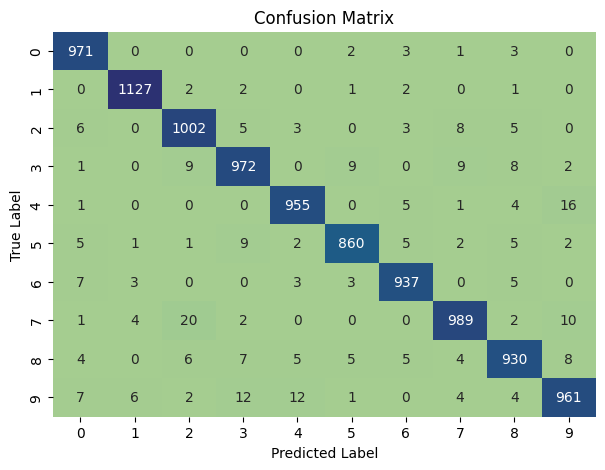

In [87]:
show_results(y_pred_rf, 'Random Forest')


Feed-Forward Neural Network Perfomance Result
Accuracy score for Feed-Forward Neural Network: 0.9799

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



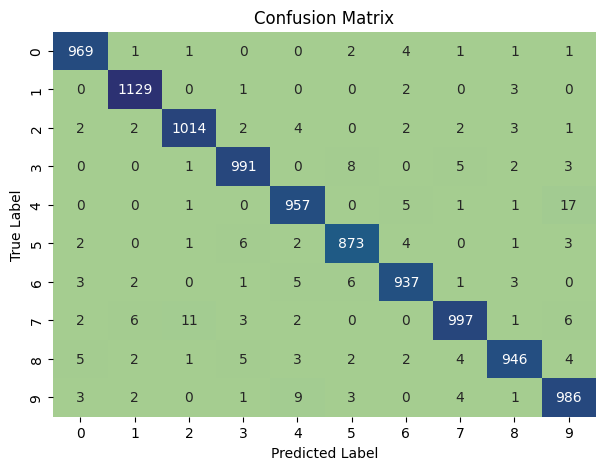

In [88]:
show_results(y_pred_nn, 'Feed-Forward Neural Network')

Convolutional Neural Network Perfomance Result
Accuracy score for Convolutional Neural Network: 0.9925

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



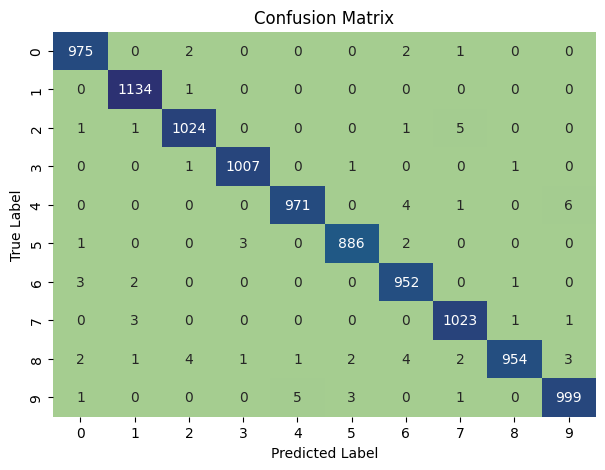

In [89]:
show_results(y_pred_cnn, 'Convolutional Neural Network')

Let's describe the key conclusions about all of these models. Overall, all three models demonstrated strong performance on the MNIST test set, with accuracy scores exceeding 97%.

- Random Forest  - a classical machine learning algorithm that achieved an accuracy of 97.04%. It delivers solid results with no need for complex hyperparameter tuning. The lowest scores, around 0.95–0.96, were observed for digits 8 and 9.

- Feed-Forward Neural Network achieved an accuracy of 97.99%, outperforming the Random Forest by less than one percentage point. Per-class precision, recall and F1-score are consistently in the 0.97–0.99 range, which indicates that the network generalizes well.

- Convolutional Neural Network achieved the highest accuracy of 99.25%. Per-class metrics are uniformly in the 0.99–1.00 range, demonstrating that CNNs provide a significant advantage for image classification tasks.

# Testing on Custom Data

To verify that our models generalize beyond the standard MNIST test set, we test them on a custom handwritten digit image. The image is located in ./task_1


In [7]:
def predict_custom_image(model, image_file, ax=None):
    #Converting to grayscale
    img = Image.open(image_file).convert('L')
    #Resizing to 28x28
    img = img.resize((28, 28))
    #converting to array and adding batch dimension
    img_batch = np.array(img)[np.newaxis, ...]

    prediction = model.predict(img_batch)

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    
    ax.imshow(img_batch[0], cmap="gist_gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(f"Predicted Digit: {prediction[0]}", fontsize = 12)
    
    return prediction[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


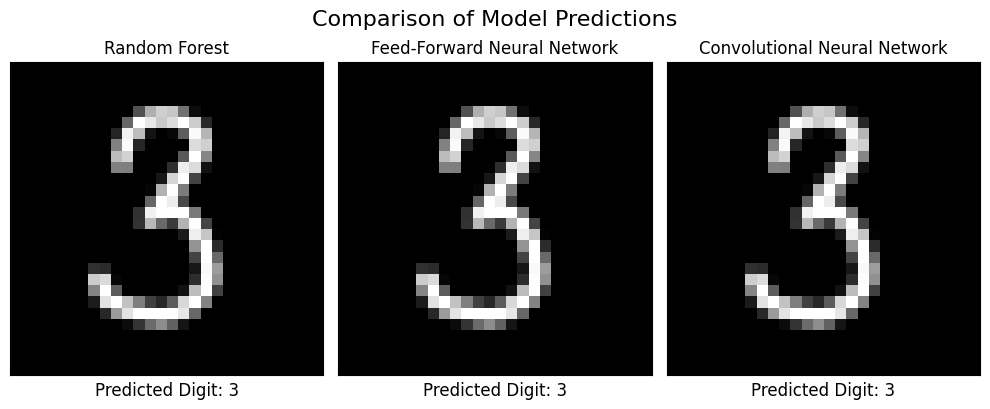

In [9]:
models_names = ["Random Forest", "Feed-Forward Neural Network", "Convolutional Neural Network"]
image_file = "data/test_img.png" 
models = [rf_clf, nn_clf, cnn_clf]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
plt.suptitle("Comparison of Model Predictions", fontsize=16)

for i, model in enumerate(models):
    predict_custom_image(model, image_file, ax=axes[i])
    axes[i].set_title(models_names[i], fontsize=12)

plt.tight_layout()

All three models (Random Forest, Feed-Forward Neural Network and Convolutional Neural Network)  correctly predicted the digit 3 from a custom handwritten image. While this does not guarantee 100% accuracy on arbitrary handwritten input, it demonstrates that the trained models are capable of generalizing to examples outside the original MNIST dataset


# Edge Cases

Although all three models demonstrate high overall accuracy, there are still cases where the predicted label does not match the true one. Such misclassifications often occur due to visual similarities between certain handwritten digits. Let's examine some examples that were incorrectly classified by each model to better understand their limitations

In [99]:
def show_misclassified(y_pred, X_test, model_name, y_test=y_test):
    misclassified_idx = np.where(y_pred != y_test)[0]
    
    plt.figure(figsize=(10, 5))
    plt.suptitle(f"Misclassified Images by {model_name}", fontsize=12)

    for i, idx in enumerate(misclassified_idx[:10]):
        
        plt.subplot(2, 5, i+1)
        plt.imshow(X_test[idx].reshape(28,28), cmap="gist_gray")
        plt.title(f"True: {y_test[idx]} VS Pred: {y_pred[idx]}")
        plt.axis("off")
    
    plt.tight_layout()

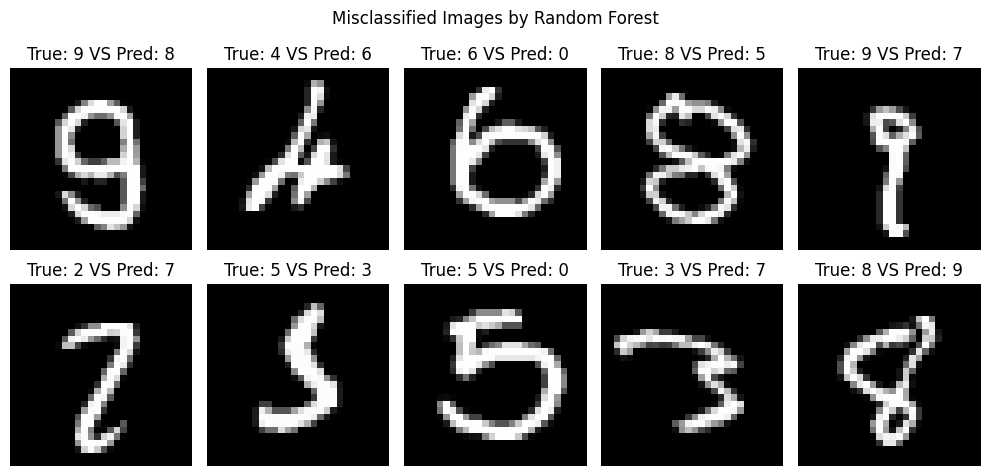

In [100]:
show_misclassified(y_pred_rf, X_test, "Random Forest")

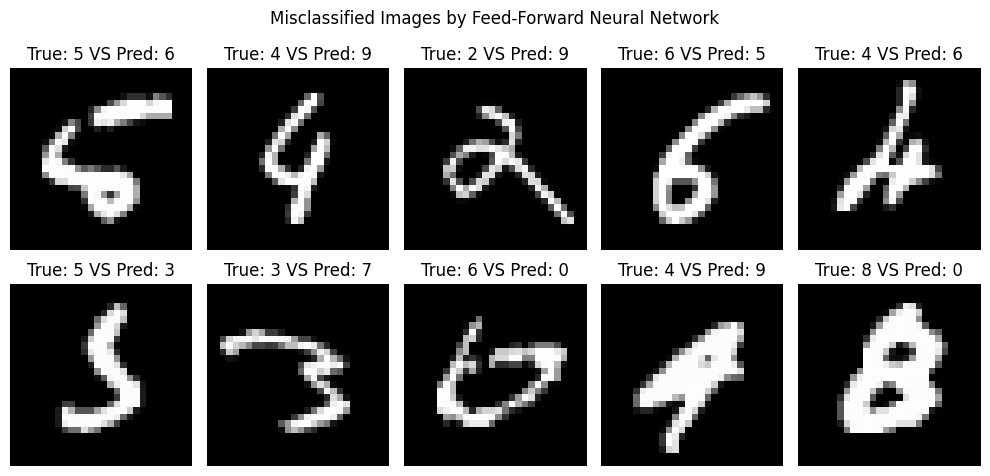

In [102]:
show_misclassified(y_pred_nn, X_test, "Feed-Forward Neural Network")

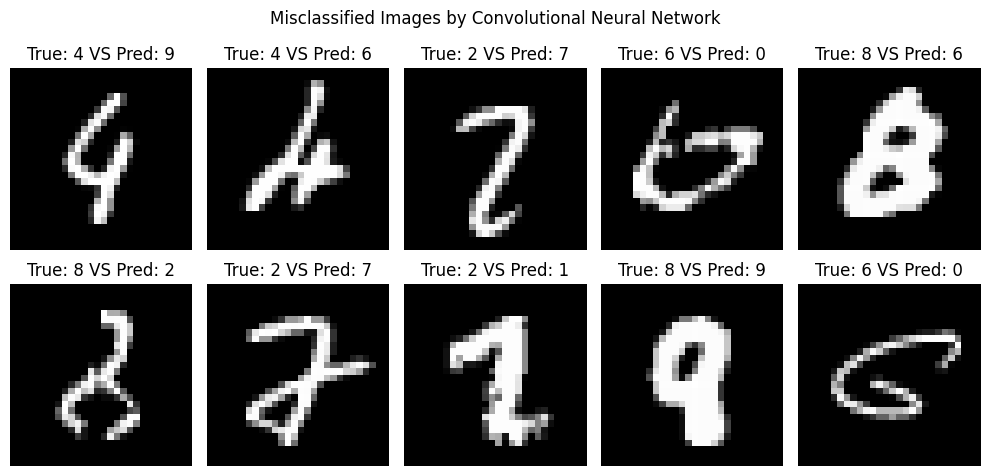

In [103]:
show_misclassified(y_pred_cnn, X_test, "Convolutional Neural Network")

Classification error examples reveal a common pattern across all models: errors tend to occur with digits that are difficult to recognize even for humans. For example, unusual handwriting, slant or overlapping visual features between classes (6 similar to 0; 2 similar to 8) are the main sources of incorrect predictions

# Conclusion

So, we performed a complete machine learning pipeline on the MNIST dataset:

- Exploratory Data Analysis: we examined the structure of the dataset, verified class distribution and visualized representative samples for each digit class

- Preprocessing & Training: the data was prepared and used to train three different classifiers: Random Forest, Feed-Forward Neural Network and Convolutional Neural Network, each implemented behind a unified MnistClassifier interface

- Model Evaluation:we assessed each model using accuracy, confusion matrix and classification report. The CNN achieved the best result (99.25%), followed by the FNN (97.99%) and Random Forest (97.04%)

- Edge Case Analysis: we identified and visualized misclassified examples, confirming that errors are primarily caused by ambiguous or atypical handwriting rather than systematic model failures

Overall, the CNN proved to be the most effective architecture for this task. At the same time, all three models demonstrated strong generalization capability, including on custom handwritten input outside the original dataset